C:\Users\veron\AppData\Local\Temp\ipykernel_10968\511664396.py:63: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,120

Rows: 24497
Medication prevalence: 0.19573825366371392
Med group: 4795
Ctrl group: 19702


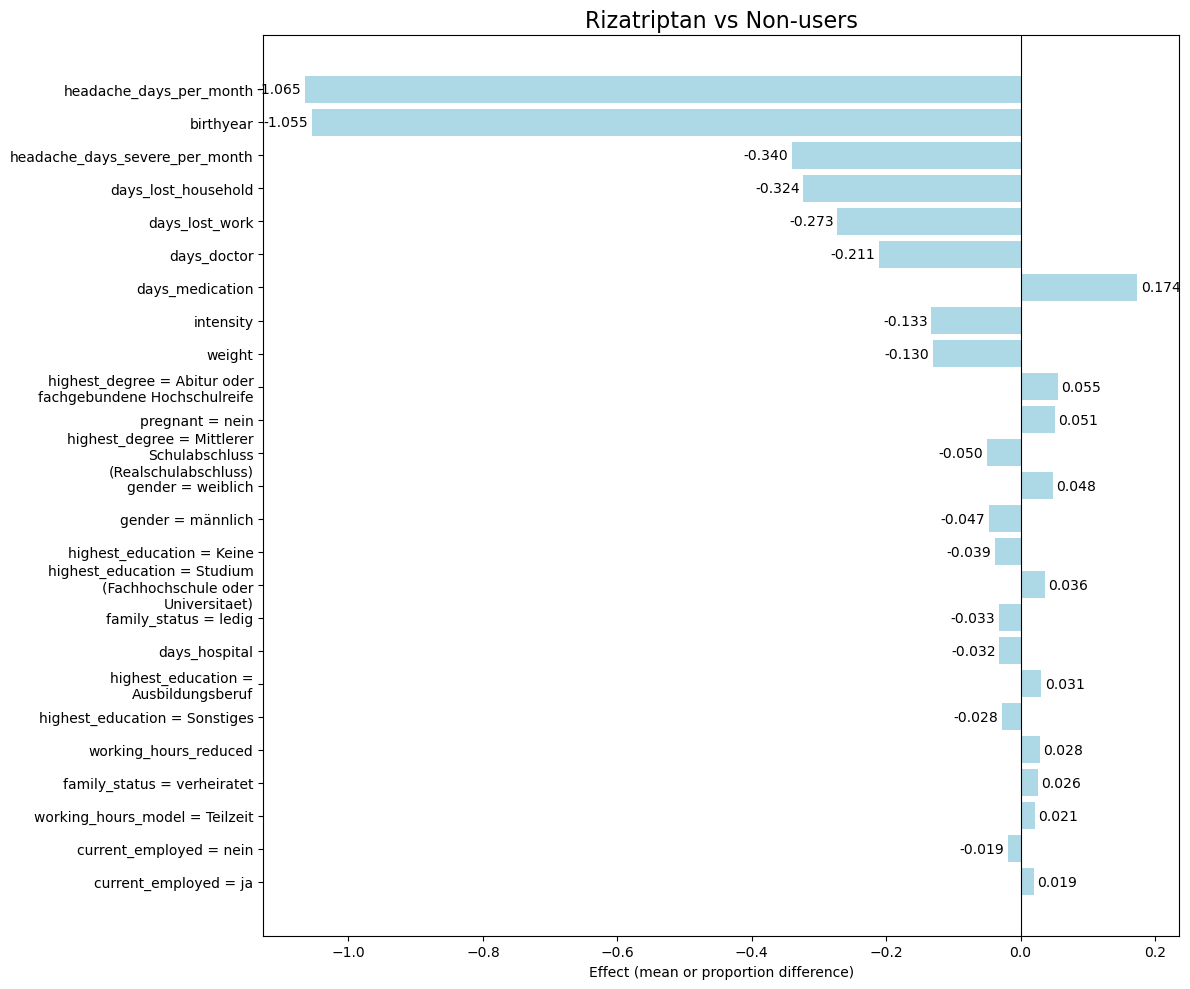

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import re
import textwrap

# =========================================================
# CONFIG
# =========================================================

DATA_DIR = Path("./patienten-visiten")
csv_files = sorted(DATA_DIR.glob("Patients_V*.csv"))

MEDICATION_QUERY = "Rizatriptan"

factor_prefixes = [
    "gender","birthyear","weight","pregnant",
    "highest_degree","highest_education","family_status",
    "current_employed","working_hours_model","shiftwork",
    "working_hours_reduced","promotion_waived","children",
    "headache_days_per_month","headache_days_severe_per_month",
    "days_medication","intensity","days_lost_work",
    "days_lost_household","days_doctor","days_ER","days_hospital"
]

# =========================================================
# SAFE K-COLLAPSE
# =========================================================

def collapse_k_columns(df, prefixes):

    out = {}

    for p in prefixes:

        cols = [c for c in df.columns if c.startswith(p)]
        if not cols:
            continue

        block = df[cols]

        sample = block.stack().dropna()
        numeric_ratio = pd.to_numeric(sample, errors="coerce").notna().mean()

        if numeric_ratio > 0.7:
            num_block = block.apply(pd.to_numeric, errors="coerce")
            out[p] = num_block.mean(axis=1)

        else:
            out[p] = block.bfill(axis=1).iloc[:, 0].astype(str)

    return pd.DataFrame(out)

# =========================================================
# LOAD DATA
# =========================================================

frames = []

for file in csv_files:

    df = pd.read_csv(file, sep=";")

    med_cols = [c for c in df.columns if c.startswith("acute_name_a")]
    if not med_cols:
        continue

    med_text = df[med_cols].astype(str).agg(" ".join, axis=1).str.lower()

    # =====================================================
    # FIXED MEDICATION DETECTION
    # =====================================================

    med_query = MEDICATION_QUERY.lower()

    df["has_med"] = med_text.str.contains(med_query, na=False)

    # keep your original logic unchanged
    df["any_med"] = med_text.str.contains(r"\w", na=False)

    collapsed = collapse_k_columns(df, factor_prefixes)

    collapsed["has_med"] = df["has_med"].values
    collapsed["any_med"] = df["any_med"].values

    frames.append(collapsed)

data = pd.concat(frames, ignore_index=True)

print("Rows:", len(data))
print("Medication prevalence:", data["has_med"].mean())

# =========================================================
# GROUPS
# =========================================================

med = data[data["has_med"]]
ctrl = data[~data["has_med"] & data["any_med"]]

if len(ctrl) < 10:
    ctrl = data[~data["has_med"]]

print("Med group:", len(med))
print("Ctrl group:", len(ctrl))

# =========================================================
# ANALYSIS
# =========================================================

results = []

for col in data.columns:

    if col in ["has_med", "any_med"]:
        continue

    m = med[col]
    c = ctrl[col]

    m_num = pd.to_numeric(m, errors="coerce")
    c_num = pd.to_numeric(c, errors="coerce")

    if m_num.notna().mean() > 0.7:

        results.append({
            "factor": col,
            "effect": m_num.mean() - c_num.mean(),
            "type": "numeric"
        })
        continue

    if m_num.dropna().isin([0, 1]).mean() > 0.95:

        results.append({
            "factor": col,
            "effect": m_num.mean() - c_num.mean(),
            "type": "binary"
        })
        continue

    cats = sorted(set(m.dropna().astype(str)) | set(c.dropna().astype(str)))

    for cat in cats:

        if cat in ["nan", "None", ""]:
            continue

        results.append({
            "factor": f"{col} = {cat}",
            "effect": (m.astype(str) == cat).mean() - (c.astype(str) == cat).mean(),
            "type": "categorical"
        })

# =========================================================
# PLOT
# =========================================================

res = pd.DataFrame(results).dropna()

res["abs"] = res["effect"].abs()
res = res.sort_values("abs").tail(25)
res["factor_wrapped"] = res["factor"].apply(lambda x: textwrap.fill(str(x), width=30))

plt.figure(figsize=(12, 10))

bars = plt.barh(res["factor_wrapped"], res["effect"], color="lightblue")
plt.axvline(0, color="black", linewidth=0.8)

plt.title(f"{MEDICATION_QUERY} vs Non-users", fontsize=16)
plt.xlabel("Effect (mean or proportion difference)")

for bar in bars:
    width = bar.get_width()
    ha = 'left' if width >= 0 else 'right'
    offset = 0.005 if width >= 0 else -0.005
    plt.text(width + offset, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center', ha=ha)

plt.tight_layout()
plt.show()

In [5]:
# =========================================================
# PREPARE ALL DATA FOR MULTI-MEDICATION ANALYSIS
# =========================================================

frames_all = []
med_text_all_parts = []

for file in csv_files:

    df_all = pd.read_csv(file, sep=";")

    med_cols_all = [
        c for c in df_all.columns
        if c.startswith("acute_name_a")
    ]

    if not med_cols_all:
        continue

    med_text_part = (
        df_all[med_cols_all]
        .astype(str)
        .agg(" ".join, axis=1)
        .str.lower()
    )

    df_all["any_med"] = med_text_part.str.contains(
        r"\w",
        na=False
    )

    collapsed_all = collapse_k_columns(
        df_all,
        factor_prefixes
    )

    collapsed_all["any_med"] = (
        df_all["any_med"].values
    )

    frames_all.append(collapsed_all)
    med_text_all_parts.append(med_text_part)


data_all = pd.concat(
    frames_all,
    ignore_index=True
)

med_text_all = pd.concat(
    med_text_all_parts,
    ignore_index=True
)

C:\Users\veron\AppData\Local\Temp\ipykernel_10968\906485256.py:10: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,120

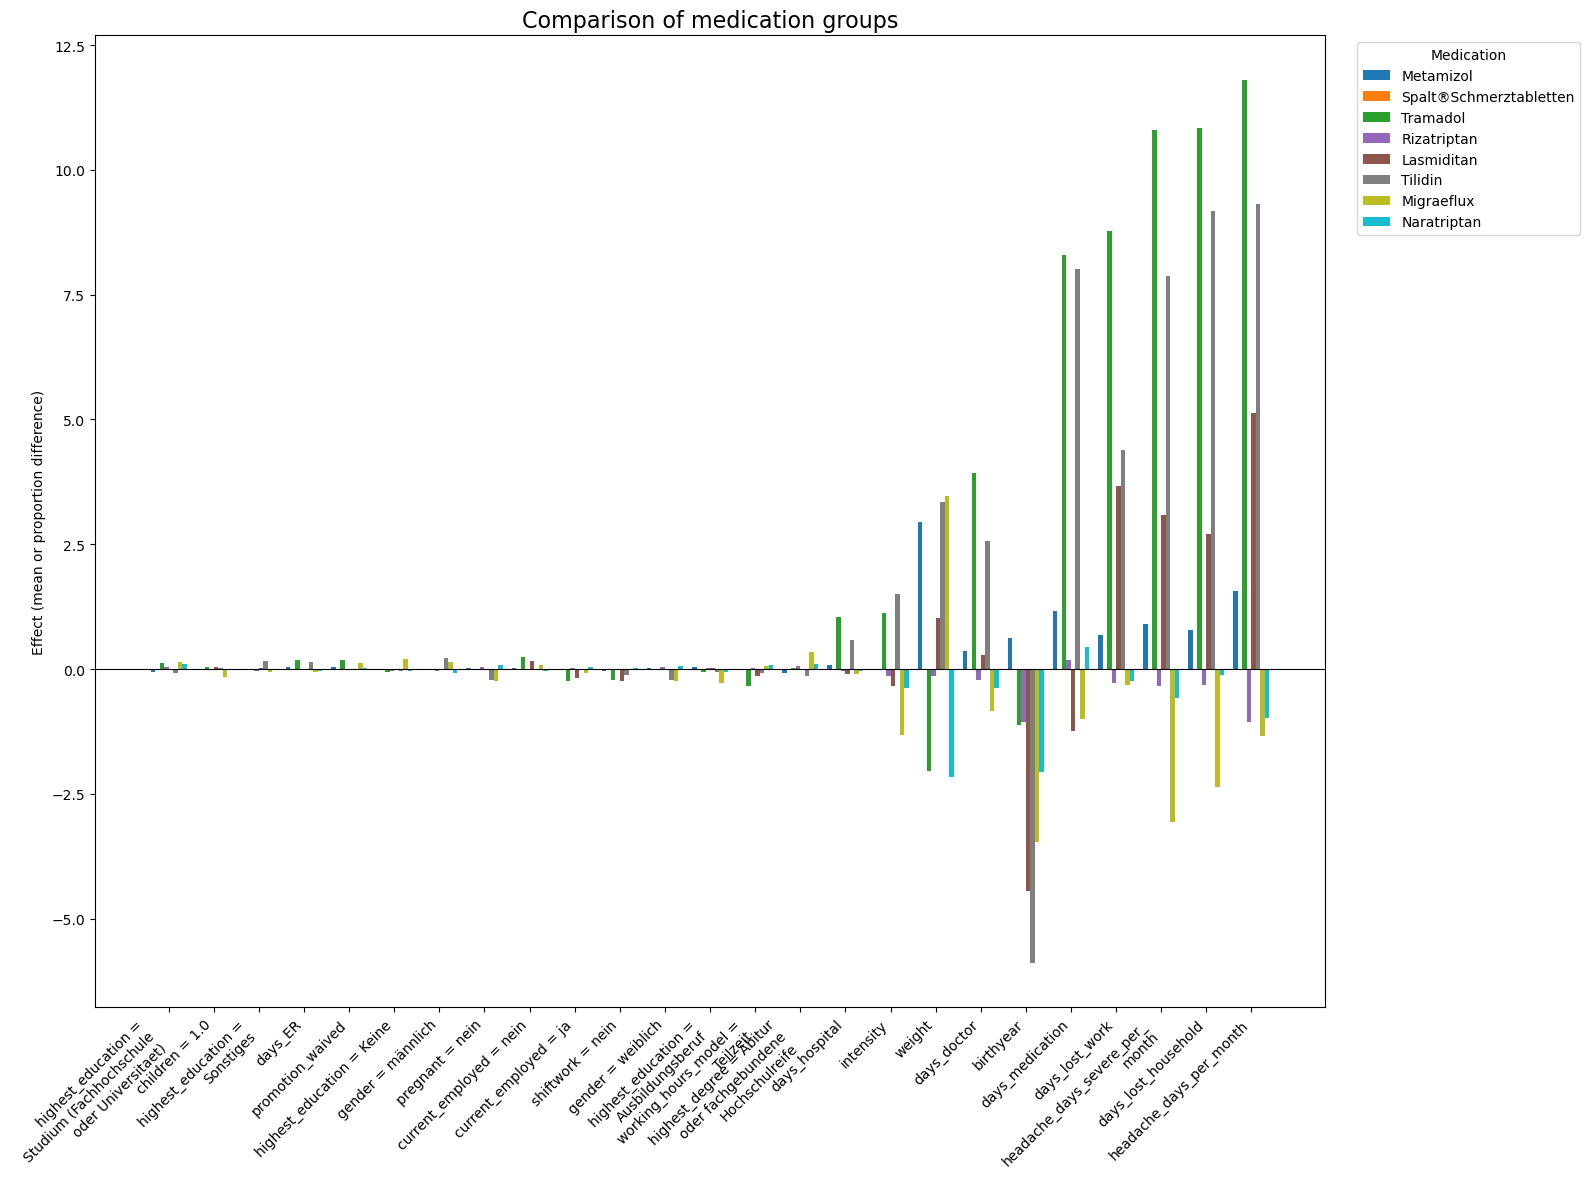

In [6]:
# =========================================================
# MULTI-MEDICATION COMPARISON
# =========================================================

MEDICATIONS = [
    "Metamizol",
    "Spalt®Schmerztabletten",
    "Tramadol",
    "Rizatriptan",
    "Lasmiditan",
    "Tilidin",
    "Migraeflux",
    "Naratriptan"
]

all_results = []

for medication in MEDICATIONS:

    # -----------------------------------------------------
    # MEDICATION DETECTION
    # -----------------------------------------------------

    med_query = medication.lower()

    med_mask = med_text_all.str.contains(
        med_query,
        na=False,
        regex=False
    )

    med_group = data_all[med_mask]

    ctrl_group = data_all[
        ~med_mask & data_all["any_med"]
    ]

    # Fallback, falls weniger als 10 Kontrollpersonen vorhanden sind
    if len(ctrl_group) < 10:
        ctrl_group = data_all[~med_mask]

    # -----------------------------------------------------
    # ANALYSIS
    # -----------------------------------------------------

    medication_results = []

    for col in data_all.columns:

        if col in ["has_med", "any_med"]:
            continue

        m = med_group[col]
        c = ctrl_group[col]

        m_num = pd.to_numeric(m, errors="coerce")
        c_num = pd.to_numeric(c, errors="coerce")

        # Numerische Variablen
        if m_num.notna().mean() > 0.7:

            medication_results.append({
                "factor": col,
                "effect": m_num.mean() - c_num.mean(),
                "medication": medication,
                "type": "numeric"
            })

            continue

        # Binäre Variablen
        if m_num.dropna().isin([0, 1]).mean() > 0.95:

            medication_results.append({
                "factor": col,
                "effect": m_num.mean() - c_num.mean(),
                "medication": medication,
                "type": "binary"
            })

            continue

        # Kategorische Variablen
        cats = sorted(
            set(m.dropna().astype(str)) |
            set(c.dropna().astype(str))
        )

        for cat in cats:

            if cat in ["nan", "None", ""]:
                continue

            medication_results.append({
                "factor": f"{col} = {cat}",
                "effect": (
                    (m.astype(str) == cat).mean()
                    -
                    (c.astype(str) == cat).mean()
                ),
                "medication": medication,
                "type": "categorical"
            })

    all_results.extend(medication_results)


# =========================================================
# PREPARE DATA
# =========================================================

all_res = pd.DataFrame(all_results).dropna()

# Die wichtigsten Faktoren über alle Medikamente hinweg bestimmen
factor_order = (
    all_res
    .assign(abs_effect=all_res["effect"].abs())
    .groupby("factor")["abs_effect"]
    .max()
    .sort_values()
    .tail(25)
    .index
)

plot_data = all_res[
    all_res["factor"].isin(factor_order)
].copy()

# Sortierung für ein gemeinsames Diagramm
plot_data["factor"] = pd.Categorical(
    plot_data["factor"],
    categories=factor_order,
    ordered=True
)

plot_data = plot_data.sort_values("factor")


# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(16, 12))

# Farben automatisch aus Matplotlib erzeugen
colors = plt.cm.tab10(np.linspace(0, 1, len(MEDICATIONS)))

color_map = dict(
    zip(MEDICATIONS, colors)
)

# Positionen für gruppierte Balken
factors = list(factor_order)
x = np.arange(len(factors))

bar_width = 0.10

for i, medication in enumerate(MEDICATIONS):

    med_data = (
        plot_data[
            plot_data["medication"] == medication
        ]
        .set_index("factor")
        .reindex(factors)
    )

    effects = med_data["effect"].fillna(0).values

    positions = (
        x
        +
        (i - len(MEDICATIONS) / 2) * bar_width
        +
        bar_width / 2
    )

    plt.bar(
        positions,
        effects,
        width=bar_width,
        label=medication,
        color=color_map[medication]
    )


plt.axhline(
    0,
    color="black",
    linewidth=0.8
)

plt.xticks(
    x,
    [
        textwrap.fill(str(factor), width=25)
        for factor in factors
    ],
    rotation=45,
    ha="right"
)

plt.ylabel(
    "Effect (mean or proportion difference)"
)

plt.title(
    "Comparison of medication groups",
    fontsize=16
)

plt.legend(
    title="Medication",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

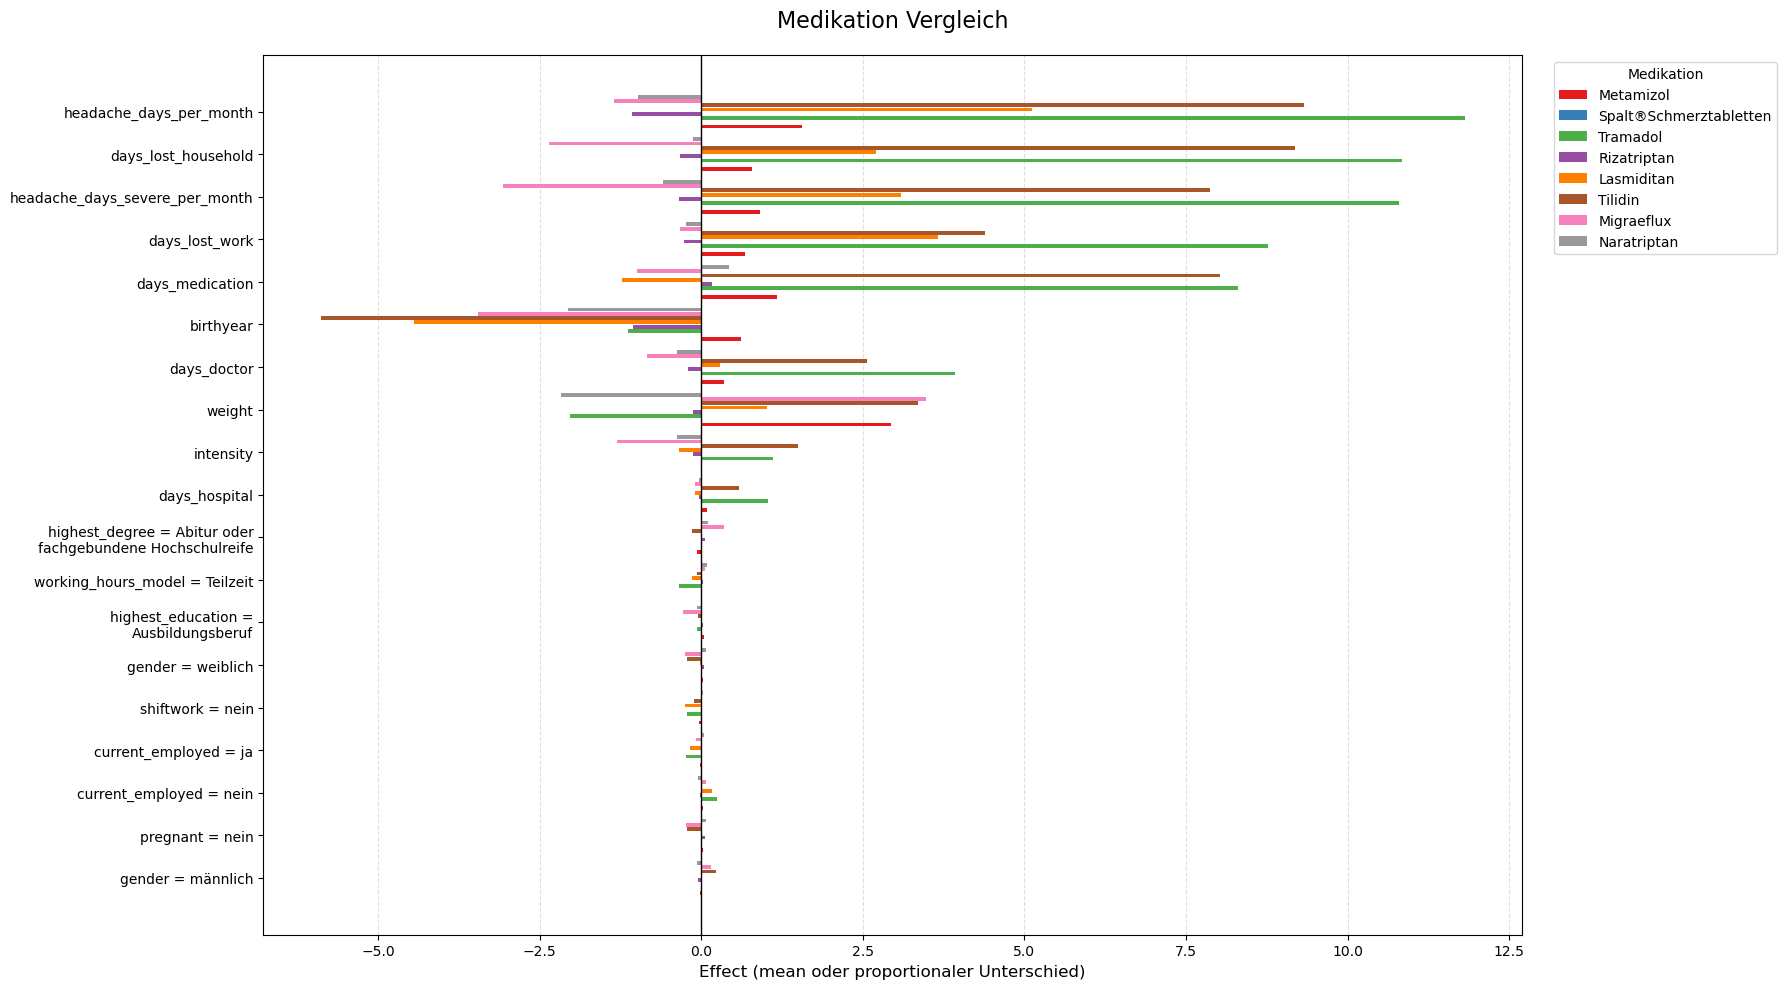

In [11]:
# =========================================================
# IMPROVED MULTI-MEDICATION COMPARISON
# =========================================================

# Faktoren mit einem maximalen Effekt unter diesem Wert
# werden vollständig ausgeschlossen.
MIN_EFFECT = 0.2

# Nur Faktoren behalten, bei denen mindestens ein Medikament
# einen ausreichend großen Effekt zeigt
factor_order = (
    all_res
    .assign(abs_effect=all_res["effect"].abs())
    .groupby("factor")["abs_effect"]
    .max()
)

factor_order = (
    factor_order[
        factor_order >= MIN_EFFECT
    ]
    .sort_values()
)

plot_data = all_res[
    all_res["factor"].isin(factor_order.index)
].copy()

# =========================================================
# FACTOR ORDER
# =========================================================

factors = list(factor_order.index)

plot_data["factor"] = pd.Categorical(
    plot_data["factor"],
    categories=factors,
    ordered=True
)

plot_data = plot_data.sort_values("factor")


# =========================================================
# PLOT
# =========================================================

fig, ax = plt.subplots(
    figsize=(18, max(10, len(factors) * 0.45))
)

# Deutlich unterscheidbare Farben
colors = [
    "#E41A1C",  # Rot
    "#377EB8",  # Blau
    "#4DAF4A",  # Grün
    "#984EA3",  # Violett
    "#FF7F00",  # Orange
    "#A65628",  # Braun
    "#F781BF",  # Pink
    "#999999"   # Grau
]

color_map = dict(
    zip(MEDICATIONS, colors)
)

# =========================================================
# HORIZONTAL GROUPED BAR CHART
# =========================================================

n_medications = len(MEDICATIONS)
bar_height = 0.8 / n_medications

y = np.arange(len(factors))

for i, medication in enumerate(MEDICATIONS):

    med_data = (
        plot_data[
            plot_data["medication"] == medication
        ]
        .set_index("factor")
        .reindex(factors)
    )

    effects = (
        med_data["effect"]
        .fillna(0)
        .values
    )

    positions = (
        y
        - 0.4
        + i * bar_height
        + bar_height / 2
    )

    ax.barh(
        positions,
        effects,
        height=bar_height * 0.9,
        label=medication,
        color=color_map[medication]
    )


# =========================================================
# AXIS AND LABELS
# =========================================================

ax.axvline(
    0,
    color="black",
    linewidth=1
)

ax.set_yticks(y)

ax.set_yticklabels(
    [
        textwrap.fill(
            str(factor),
            width=35
        )
        for factor in factors
    ],
    fontsize=10
)

ax.set_xlabel(
    "Effect (mean oder proportionaler Unterschied)",
    fontsize=12
)

ax.set_title(
    f"Medikation Vergleich",
    fontsize=16,
    pad=20
)


# =========================================================
# GRID AND LEGEND
# =========================================================

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

ax.set_axisbelow(True)

ax.legend(
    title="Medikation",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=10
)

plt.tight_layout()

plt.show()